# HGFND — Combined Best Hyperedges

**Dataset (parameter):** `DATASET = 'politifact'`  
**Seeds:** 7 · **Configs:** 4 · **Total runs:** 28

Compares the HGFND baseline against the **best configuration from each
individual sweep**, plus their combination:

| Config | Hyperedges added | Source |
|---|---|---|
| Baseline | none | HGFND paper |
| +Sentiment | NEG + NEU + POS (VADER 3-class, title) | sentiment sweep v2 best |
| +Verification | Above ≥5% + Below ≥5% (verified-user ratio) | threshold sweep v2 best |
| +Sent+Verif | All 5 hyperedges combined | new — tests synergy |

**Key question:** Does stacking both extensions beat either alone?


In [ ]:
import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}  '
      f'({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"})')


PyTorch : 2.11.0+cu128
CUDA    : True  (Tesla T4)


In [ ]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

pip('torch_geometric')
pip('gdown')
pip('nltk')

# torch_scatter / torch_sparse — try wheel matching current torch+cuda
import torch as _t
_v  = _t.__version__.split('+')[0]
_cu = 'cu' + _t.version.cuda.replace('.', '') if _t.cuda.is_available() else 'cpu'
_base = f'https://data.pyg.org/whl/torch-{_v}+{_cu}.html'
try:
    pip('torch_scatter', 'torch_sparse', '-f', _base)
except Exception as e:
    print(f'Wheel install failed ({e}), falling back to source.')
    pip('torch_scatter', 'torch_sparse')

print('All dependencies installed.')


All dependencies installed.


In [ ]:
import os

if not os.path.isdir('IEEEBigdata22_HGFND'):
    os.system('git clone https://github.com/ujeong1/IEEEBigdata22_HGFND.git')
os.chdir('IEEEBigdata22_HGFND')
print('Working directory:', os.getcwd())


Working directory: /content/IEEEBigdata22_HGFND


In [ ]:
import os
# Use os.system instead of subprocess.check_call — avoids CalledProcessError
# when minor version conflicts exist in requirements.txt on Colab's Python 3.12
os.system('pip install -q -r requirements.txt')
print('requirements.txt installed.')

requirements.txt installed.


In [ ]:
import sys, types, torch

# torch_sparse fallback for environments where the wheel isn't available
try:
    import torch_sparse
    print('torch_sparse: OK')
except ModuleNotFoundError:
    from torch_geometric.utils import coalesce as _pyg_coalesce
    torch_sparse = types.ModuleType('torch_sparse')
    def _coalesce(edge_index, edge_attr, ns, nd):
        return _pyg_coalesce(edge_index, edge_attr, max(ns, nd))
    torch_sparse.coalesce = _coalesce
    sys.modules['torch_sparse'] = torch_sparse
    print('torch_sparse: using PyG native coalesce fallback')

# torch.load patch for PyTorch 2.6+ (weights_only default changed)
_orig_load = torch.load
def _patched_load(*a, **kw):
    kw.setdefault('weights_only', False)
    return _orig_load(*a, **kw)
torch.load = _patched_load
print('torch.load: patched for PyTorch 2.6+ compatibility')

# VADER lexicon
import nltk
nltk.download('vader_lexicon', quiet=True)
print('VADER lexicon: OK')


torch_sparse: OK
torch.load: patched for PyTorch 2.6+ compatibility
VADER lexicon: OK


In [ ]:
import gdown, zipfile, os

GDRIVE_FOLDER_ID = '1OslTX91kLEYIi2WBnwuFtXsVz5SS_XeR'
pol_ready = os.path.exists('data/politifact/raw/node_graph_id.npy')

if not pol_ready:
    if not os.path.exists('data_download/politifact.zip'):
        print('Downloading PolitiFact dataset from Google Drive...')
        gdown.download_folder(id=GDRIVE_FOLDER_ID, output='data_download', quiet=False)
    os.makedirs('data/politifact/raw', exist_ok=True)
    with zipfile.ZipFile('data_download/politifact.zip', 'r') as z:
        z.extractall('data/politifact/raw/')
    print('PolitiFact extracted.')
else:
    print('PolitiFact already present, skipping download.')

assert os.path.isfile('data/pol_news_text.pkl'), 'data/pol_news_text.pkl missing from repo'
assert os.path.isfile('data/pol_news_list.txt'), 'data/pol_news_list.txt missing from repo'
print('All required data files found.')
print('data/politifact/raw:', os.listdir('data/politifact/raw/'))


Retrieving folder contents


Processing file 1DkMAzC7XUUciAxsSujRJt3sq1MqaVI3g gossipcop.zip
Processing file 1toou2GO0agoY_OS54LaCWEECQfe93nuq politifact.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1DkMAzC7XUUciAxsSujRJt3sq1MqaVI3g
From (redirected): https://drive.google.com/uc?id=1DkMAzC7XUUciAxsSujRJt3sq1MqaVI3g&confirm=t&uuid=560aacdb-0d4e-457b-8d98-f2b67a668a7e
To: /content/IEEEBigdata22_HGFND/data_download/gossipcop.zip
100%|██████████| 1.40G/1.40G [00:21<00:00, 66.4MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1toou2GO0agoY_OS54LaCWEECQfe93nuq
From (redirected): https://drive.google.com/uc?id=1toou2GO0agoY_OS54LaCWEECQfe93nuq&confirm=t&uuid=4105e44e-f3c9-4bff-b17c-61307e25b153
To: /content/IEEEBigdata22_HGFND/data_download/politifact.zip
100%|██████████| 198M/198M [00:03<00:00, 53.6MB/s]
Download completed


PolitiFact extracted.
All required data files found.
data/politifact/raw: ['train_idx.npy', 'test_idx.npy', 'graph_labels.npy', 'new_profile_feature.npz', 'new_spacy_feature.npz', 'new_content_feature.npz', 'node_graph_id.npy', 'new_bert_feature.npz', 'A.txt', 'val_idx.npy']


In [ ]:
import argparse, torch

# ── PARAMETER ─────────────────────────────────────────────────────────────────
DATASET = 'politifact'   # ← change here to switch dataset
# ─────────────────────────────────────────────────────────────────────────────

EPOCHS = 200
SEEDS  = [42, 2026, 33, 123, 456, 789, 1000]  # same 7 seeds as individual sweeps

# ── 4 configurations ──────────────────────────────────────────────────────────
# scheme controls which hyperedges are appended to the base set:
#   None          → Baseline (HGFND paper — no extra hyperedges)
#   'sentiment'   → NEG + NEU + POS (VADER 3-class title, best from sentiment v2)
#   'verification'→ Above ≥5% + Below ≥5% verified-user ratio (best from threshold v2)
#   'combined'    → all 5 hyperedges (sentiment + verification)
CONFIGS = [
    {'label': 'Baseline',      'scheme': None,           'color': '#546E7A', 'ls': '-' },
    {'label': '+Sentiment',    'scheme': 'sentiment',    'color': '#C62828', 'ls': '-' },
    {'label': '+Verification', 'scheme': 'verification', 'color': '#1565C0', 'ls': '-' },
    {'label': '+Sent+Verif',   'scheme': 'combined',     'color': '#6A1B9A', 'ls': '-' },
]

args = argparse.Namespace(
    dataset      = DATASET,
    hiddenSize   = 128,
    dropout      = 0.3,
    lr           = 0.001,
    weight_decay = 0.01,
    batchSize    = 128,
    epoch        = EPOCHS,
    shuffle      = True,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device    : {device}')
print(f'Dataset   : {DATASET}')
print(f'Seeds     : {SEEDS}  (n={len(SEEDS)})')
print(f'Epochs    : {EPOCHS}')
print(f'Configs   : {len(CONFIGS)}  ({[c["label"] for c in CONFIGS]})')
print(f'Total runs: {len(SEEDS) * len(CONFIGS)}  '
      f'(~{len(SEEDS)*len(CONFIGS)*3//60}–{len(SEEDS)*len(CONFIGS)*4//60} min on T4)')


Device    : cuda
Dataset   : politifact
Seeds     : [42, 2026, 33, 123, 456, 789, 1000]  (n=7)
Epochs    : 200
Configs   : 4  (['Baseline', '+Sentiment', '+Verification', '+Sent+Verif'])
Total runs: 28  (~1–1 min on T4)


In [ ]:
import copy, random, pickle
import numpy as np
import scipy.sparse as sp
import torch
import torch.nn.functional as F
from torch.utils.data import random_split
from torch_geometric.data import DataLoader
from sklearn import metrics
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from utils.data_loader import FNNDataset, ToUndirected

dataset = FNNDataset(root='data', feature='bert', empty=False,
                     name=args.dataset, transform=ToUndirected())
args.num_classes  = dataset.num_classes
args.num_features = dataset.num_features

all_loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
for data in all_loader:
    data            = data.to(device)
    data_batch      = data.batch
    data_edge_index = data.edge_index
    data_nodes      = data.x
    data_labels     = data.y

nodes_seq = np.arange(len(data_labels))
print(f'Graphs   : {len(dataset)}  ({args.num_classes} classes, {args.num_features} features)')
print(f'Nodes    : {data_nodes.shape[0]}')
print(f'Labels   : {dict(zip(*np.unique(data_labels.cpu().numpy(), return_counts=True)))}')
print('(label 0 = real, label 1 = fake)')


data/politifact/raw/


Processing...
Done!


Graphs   : 314  (2 classes, 768 features)
Nodes    : 41054
Labels   : {np.int64(0): np.int64(157), np.int64(1): np.int64(157)}
(label 0 = real, label 1 = fake)


## Phase 3 — Hyperedge Construction

Two sets of extra hyperedges are pre-computed once and reused across all runs:

**Sentiment (VADER 3-class, best from sentiment sweep v2):**
- NEGATIVE (compound ≤ −0.05): 87 articles, 70 % fake
- NEUTRAL  (−0.05 < compound < +0.05): 130 articles, 65 % real
- POSITIVE (compound ≥ +0.05): 97 articles, 52 % fake

**Verification (≥5 % threshold, best from threshold sweep v2):**
- Above ≥5 %: articles where verified users make up ≥5 % of sharers
- Below ≥5 %: the rest


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from utils.hypergraph import Hypergraph

# ── Base hyperedges (original HGFND) ─────────────────────────────────────────
builder         = Hypergraph(args)
base_hyperedges = builder.get_hyperedges()
print(f'Base hyperedges : {len(base_hyperedges)}')

# ── Sentiment hyperedges (VADER 3-class, title ≤150 chars) ───────────────────
with open('data/pol_news_text.pkl', 'rb') as fh:
    text_dict = pickle.load(fh)
with open('data/pol_news_list.txt') as fh:
    news_list = [ln.strip() for ln in fh]

sia = SentimentIntensityAnalyzer()
title_compounds = np.array([
    sia.polarity_scores(text_dict.get(nid, '').split('\n')[0][:150])['compound']
    for nid in news_list
])

sent_neg = [int(i) for i, c in enumerate(title_compounds) if c <= -0.05]
sent_neu = [int(i) for i, c in enumerate(title_compounds) if -0.05 < c < 0.05]
sent_pos = [int(i) for i, c in enumerate(title_compounds) if c >= 0.05]
sentiment_edges = [sent_neg, sent_neu, sent_pos]

print(f'\nSentiment hyperedges (VADER 3-class, title):')
graph_labels = np.load(f'data/{DATASET}/raw/graph_labels.npy')
for name, grp in [('NEGATIVE', sent_neg), ('NEUTRAL', sent_neu), ('POSITIVE', sent_pos)]:
    n_fake = sum(graph_labels[i] == 1 for i in grp)
    print(f'  {name:10s}: {len(grp):3d} articles  {100*n_fake//len(grp)}% fake')

# ── Verification hyperedges (≥5% verified-user ratio) ────────────────────────
VERIF_THRESHOLD = 0.05

profile      = sp.load_npz(f'data/{DATASET}/raw/new_profile_feature.npz')
node_gid     = np.load(f'data/{DATASET}/raw/node_graph_id.npy')
verified_col = profile.toarray()[:, 0]   # column 0 = verified flag
n_news       = int(node_gid.max()) + 1
vsum = np.zeros(n_news); cnts = np.zeros(n_news)
for ni, gi in enumerate(node_gid):
    vsum[gi] += verified_col[ni]; cnts[gi] += 1
vfrac = vsum / np.maximum(cnts, 1)

verif_above = [int(i) for i in np.where(vfrac >= VERIF_THRESHOLD)[0]]
verif_below = [int(i) for i in np.where(vfrac <  VERIF_THRESHOLD)[0]]
verification_edges = [verif_above, verif_below]

print(f'\nVerification hyperedges (threshold={VERIF_THRESHOLD*100:.0f}%):')
for name, grp in [('Above ≥5%', verif_above), ('Below <5%', verif_below)]:
    n_fake = sum(graph_labels[i] == 1 for i in grp)
    print(f'  {name:12s}: {len(grp):3d} articles  {100*n_fake//max(len(grp),1)}% fake')

print(f'\nTotal extra hyperedges:')
print(f'  Sentiment   : {len(sentiment_edges)}')
print(f'  Verification: {len(verification_edges)}')
print(f'  Combined    : {len(sentiment_edges) + len(verification_edges)}')


Base hyperedges : 5710

Sentiment hyperedges (VADER 3-class, title):
  NEGATIVE  :  87 articles  70% fake
  NEUTRAL   : 130 articles  34% fake
  POSITIVE  :  97 articles  52% fake

Verification hyperedges (threshold=5%):
  Above ≥5%   :  81 articles  11% fake
  Below <5%   : 233 articles  63% fake

Total extra hyperedges:
  Sentiment   : 3
  Verification: 2
  Combined    : 5


## Phase 4 — Training Helpers


In [ ]:
from gnn_model.model import HGFND, PropagationEncoder


def build_model_and_ht(cfg, seed):
    """
    Assemble incidence matrix HT and a freshly seeded model for one config.

    cfg['scheme']:
      None           → base hyperedges only (Baseline)
      'sentiment'    → base + [NEG, NEU, POS]
      'verification' → base + [above_≥5%, below_<5%]
      'combined'     → base + [NEG, NEU, POS, above_≥5%, below_<5%]
    """
    scheme = cfg['scheme']
    if scheme is None:
        all_edges = base_hyperedges
    elif scheme == 'sentiment':
        all_edges = base_hyperedges + sentiment_edges
    elif scheme == 'verification':
        all_edges = base_hyperedges + verification_edges
    elif scheme == 'combined':
        all_edges = base_hyperedges + sentiment_edges + verification_edges
    else:
        raise ValueError(f'Unknown scheme: {scheme!r}')

    _, HT_lst, _ = builder.get_adj_matrix(all_edges, nodes_seq)
    HT_t = torch.Tensor(np.array(HT_lst)).float().to(device)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    hg  = HGFND(args)
    mdl = PropagationEncoder(args, hg).to(device)
    opt = torch.optim.Adam(mdl.parameters(), lr=args.lr, weight_decay=args.weight_decay)
    return mdl, opt, HT_t, len(all_edges)


def run_training(mdl, opt, HT_t, train_idx, val_idx):
    num_tr   = len(train_idx)
    best_val = 0.0
    best_sd  = None
    tr_losses, val_accs = [], []

    for epoch in range(1, args.epoch + 1):
        mdl.train()
        total = 0.0
        for i in range(0, num_tr, args.batchSize):
            sl  = train_idx[i : i + args.batchSize]
            opt.zero_grad()
            out, _ = mdl(data_nodes, data_edge_index, HT_t, data_batch, sl)
            loss   = F.nll_loss(mdl.compute_scores(out), data_labels[sl])
            loss.backward()
            opt.step()
            total += float(loss) * len(sl)
        tr_losses.append(total / num_tr)

        mdl.eval()
        preds = []
        with torch.no_grad():
            for i in range(0, len(val_idx), args.batchSize):
                sl     = val_idx[i : i + args.batchSize]
                out, _ = mdl(data_nodes, data_edge_index, HT_t, data_batch, sl)
                preds += list(mdl.compute_scores(out).argmax(dim=-1).cpu().numpy())
        va = metrics.accuracy_score(data_labels[val_idx].cpu().numpy(), preds)
        val_accs.append(va)
        if va > best_val:
            best_val = va
            best_sd  = copy.deepcopy(mdl.state_dict())

        if epoch % 20 == 0 or epoch <= 3:
            print(f'  Ep {epoch:03d}  loss={tr_losses[-1]:.4f}  '
                  f'val={va:.4f}  best={best_val:.4f}')

    return best_sd, tr_losses, val_accs, best_val


def do_test(mdl, best_sd, HT_t, test_idx):
    mdl.load_state_dict(best_sd)
    mdl.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(test_idx), args.batchSize):
            sl     = test_idx[i : i + args.batchSize]
            out, _ = mdl(data_nodes, data_edge_index, HT_t, data_batch, sl)
            preds += list(mdl.compute_scores(out).argmax(dim=-1).cpu().numpy())
    truth = data_labels[test_idx].cpu().numpy()
    return {
        'accuracy'  : metrics.accuracy_score(truth, preds),
        'f1_macro'  : metrics.f1_score(truth, preds, average='macro'),
        'f1_micro'  : metrics.f1_score(truth, preds, average='micro'),
        'precision' : metrics.precision_score(truth, preds, average='macro', zero_division=0),
        'recall'    : metrics.recall_score(truth, preds, average='macro', zero_division=0),
    }

print('Training helpers ready.')


Training helpers ready.


## Phase 5 — Sweep: 4 Configs × 7 Seeds = 28 Runs

Expected runtime: ~35–50 min on Colab T4.


In [ ]:
all_results = {cfg['label']: {'train_losses': [], 'val_accs': [], 'metrics': []}
               for cfg in CONFIGS}

n_tr = int(len(dataset) * 0.2)    # 62 train
n_vl = int(len(dataset) * 0.1)    # 31 val
n_te = len(dataset) - n_tr - n_vl # 221 test

total_runs = len(SEEDS) * len(CONFIGS)
run_num    = 0

for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    tr_set, vl_set, te_set = random_split(dataset, [n_tr, n_vl, n_te])
    train_idx = list(tr_set.indices)
    val_idx   = list(vl_set.indices)
    test_idx  = list(te_set.indices)

    print(f'\n{"#"*65}')
    print(f'SEED {seed}  —  train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}')
    print(f'{"#"*65}')

    for cfg in CONFIGS:
        run_num += 1
        lbl = cfg['label']
        print(f'\n{"="*60}')
        print(f'Run {run_num}/{total_runs}  |  {lbl}  |  seed={seed}')
        print(f'{"="*60}')

        mdl, opt, HT_t, n_edges = build_model_and_ht(cfg, seed)
        print(f'Hyperedges total: {n_edges}\n')

        best_sd, tr_losses, val_accs, best_val = run_training(
            mdl, opt, HT_t, train_idx, val_idx)
        test_m = do_test(mdl, best_sd, HT_t, test_idx)

        all_results[lbl]['train_losses'].append(tr_losses)
        all_results[lbl]['val_accs'].append(val_accs)
        all_results[lbl]['metrics'].append(test_m)

        print(f'\nBest val  : {best_val:.4f}')
        print('Test  ->  ' + '  '.join(f'{k}={v:.4f}' for k, v in test_m.items()))

print(f'\n{"ok "*3} All {total_runs} runs complete.')



#################################################################
SEED 42  —  train=62  val=31  test=221
#################################################################

Run 1/28  |  Baseline  |  seed=42
Hyperedges total: 5710

  Ep 001  loss=0.6990  val=0.3871  best=0.3871
  Ep 002  loss=0.6871  val=0.3871  best=0.3871
  Ep 003  loss=0.6880  val=0.3871  best=0.3871
  Ep 020  loss=0.6020  val=0.3871  best=0.4194
  Ep 040  loss=0.1913  val=0.8710  best=0.9032
  Ep 060  loss=0.2155  val=0.7742  best=0.9032
  Ep 080  loss=0.1030  val=0.8710  best=0.9032
  Ep 100  loss=0.0527  val=0.8387  best=0.9032
  Ep 120  loss=0.0810  val=0.8710  best=0.9032
  Ep 140  loss=0.1630  val=0.8710  best=0.9032
  Ep 160  loss=0.0231  val=0.8710  best=0.9032
  Ep 180  loss=0.0479  val=0.8387  best=0.9032
  Ep 200  loss=0.0437  val=0.8065  best=0.9032

Best val  : 0.9032
Test  ->  accuracy=0.9412  f1_macro=0.9411  f1_micro=0.9412  precision=0.9440  recall=0.9414

Run 2/28  |  +Sentiment  |  seed=42
Hyperedg

## Phase 6 — Training Curves


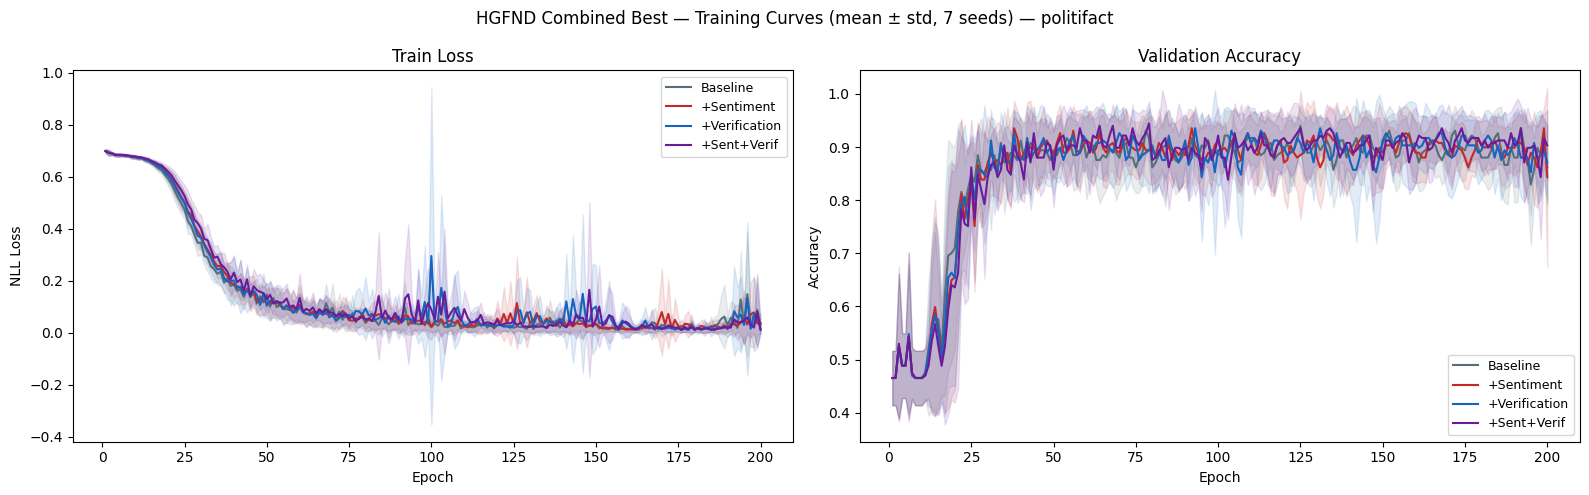

Figure saved → combined_best_curves_politifact.png


In [ ]:
ep = np.arange(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    f'HGFND Combined Best — Training Curves (mean ± std, {len(SEEDS)} seeds) — {DATASET}',
    fontsize=12)

for cfg in CONFIGS:
    lbl = cfg['label']
    res = all_results[lbl]
    if not res['train_losses']:
        continue
    tl = np.array(res['train_losses'])
    va = np.array(res['val_accs'])

    axes[0].plot(ep, tl.mean(0), color=cfg['color'], ls=cfg['ls'], lw=1.5, label=lbl)
    axes[0].fill_between(ep, tl.mean(0) - tl.std(0), tl.mean(0) + tl.std(0),
                         color=cfg['color'], alpha=0.12)

    axes[1].plot(ep, va.mean(0), color=cfg['color'], ls=cfg['ls'], lw=1.5, label=lbl)
    axes[1].fill_between(ep, va.mean(0) - va.std(0), va.mean(0) + va.std(0),
                         color=cfg['color'], alpha=0.12)

axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('NLL Loss')
axes[0].legend(fontsize=9)

axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'combined_best_curves_{DATASET}.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Figure saved → combined_best_curves_{DATASET}.png')


## Phase 7 — Results Summary


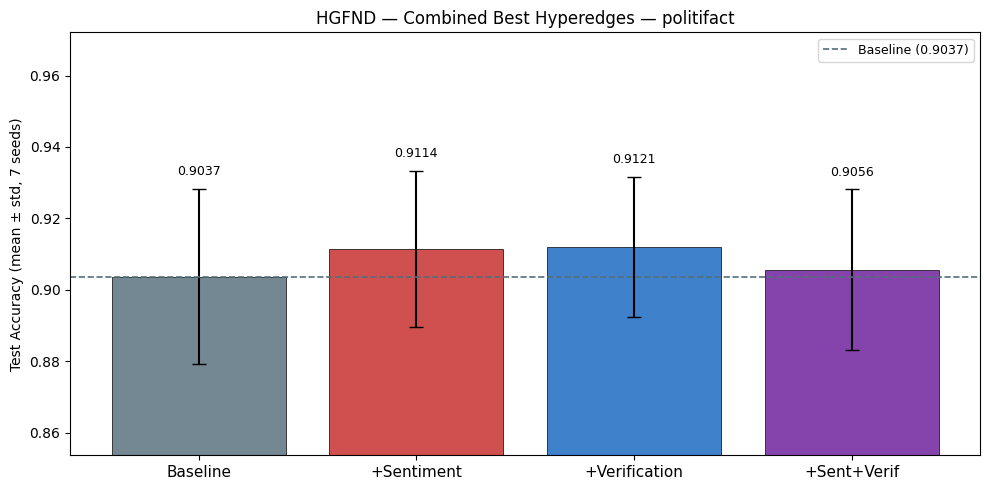

Figure saved → combined_best_bars_politifact.png


In [ ]:
# ── Accuracy bar chart ────────────────────────────────────────────────────────
means  = []
stds   = []
labels = []
colors = []
for cfg in CONFIGS:
    lbl  = cfg['label']
    res  = all_results[lbl]
    accs = [m['accuracy'] for m in res['metrics']] if res['metrics'] else [0]
    means.append(np.mean(accs))
    stds.append(np.std(accs))
    labels.append(lbl)
    colors.append(cfg['color'])

bl_acc = means[0]
x      = np.arange(len(CONFIGS))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x, means, color=colors, alpha=0.82, edgecolor='k', lw=0.6,
              yerr=stds, capsize=5)
ax.axhline(bl_acc, color='#546E7A', ls='--', lw=1.2, label=f'Baseline ({bl_acc:.4f})')
for b, m, s in zip(bars, means, stds):
    ax.text(b.get_x() + b.get_width() / 2, m + s + 0.003,
            f'{m:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Test Accuracy (mean ± std, 7 seeds)')
ax.set_title(f'HGFND — Combined Best Hyperedges — {DATASET}')
ax.set_ylim(max(0, min(means) - 0.05), min(1, max(means) + 0.06))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'combined_best_bars_{DATASET}.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Figure saved → combined_best_bars_{DATASET}.png')


In [ ]:
from scipy import stats

sep  = '=' * 70
sep2 = '-' * 70

def get_accs(lbl):
    return [m['accuracy'] for m in all_results[lbl]['metrics']]

baseline_accs = get_accs('Baseline')
b_mean        = float(np.mean(baseline_accs))

print(sep)
print(f'HGFND COMBINED BEST — STATISTICAL SUMMARY  ({DATASET.upper()})')
print(sep)
print(f'\n  Baseline (7 seeds): {b_mean:.4f} ± {np.std(baseline_accs):.4f}')
print(f'  Seeds  : {SEEDS}\n')

# ── Q1: Does each extension beat baseline? ───────────────────────────────────
print('Q1. Individual extensions vs baseline:')
for lbl in ('+Sentiment', '+Verification'):
    accs  = get_accs(lbl)
    delta = np.mean(accs) - b_mean
    t, p  = stats.ttest_ind(accs, baseline_accs)
    sign  = '+' if delta >= 0 else ''
    verdict = 'IMPROVEMENT' if delta > 0.005 else ('REGRESSION' if delta < -0.005 else 'NEGLIGIBLE')
    print(f'  {lbl:<18}  acc={np.mean(accs):.4f}  delta={sign}{delta:.4f}  '
          f't={t:.2f}  p={p:.3f}  [{verdict}]')

# ── Q2: Does the combined config beat both? (synergy test) ───────────────────
print()
print('Q2. Combined vs individual extensions (synergy test):')
accs_s  = get_accs('+Sentiment')
accs_v  = get_accs('+Verification')
accs_c  = get_accs('+Sent+Verif')
best_single = max(np.mean(accs_s), np.mean(accs_v))
delta_c = np.mean(accs_c) - b_mean
t_vs_s, p_vs_s = stats.ttest_ind(accs_c, accs_s)
t_vs_v, p_vs_v = stats.ttest_ind(accs_c, accs_v)
print(f'  +Sentiment    : {np.mean(accs_s):.4f}')
print(f'  +Verification : {np.mean(accs_v):.4f}')
print(f'  +Sent+Verif   : {np.mean(accs_c):.4f}  (delta vs baseline: {delta_c:+.4f})')
if np.mean(accs_c) > best_single + 0.002:
    print(f'  -> SYNERGY: combined beats both individually')
elif np.mean(accs_c) >= best_single - 0.001:
    print(f'  -> NO SYNERGY: combined ≈ best single (additive, not multiplicative)')
else:
    print(f'  -> INTERFERENCE: combined worse than best single')
print(f'  Combined vs +Sent   : t={t_vs_s:.2f}  p={p_vs_s:.3f}')
print(f'  Combined vs +Verif  : t={t_vs_v:.2f}  p={p_vs_v:.3f}')

# ── Full results table ────────────────────────────────────────────────────────
print()
print(sep)
print('FULL RESULTS TABLE')
print(sep2)
print(f'  {"Config":<18}  {"acc":>7}  {"±std":>7}  {"delta":>8}  '
      f'{"f1_mac":>7}  {"f1_mic":>7}  {"verdict"}')
print(sep2)
for cfg in CONFIGS:
    lbl  = cfg['label']
    res  = all_results[lbl]
    accs = [m['accuracy']  for m in res['metrics']] if res['metrics'] else []
    f1ms = [m['f1_macro']  for m in res['metrics']] if res['metrics'] else []
    f1mi = [m['f1_micro']  for m in res['metrics']] if res['metrics'] else []
    if not accs:
        print(f'  {lbl:<18}  (no results)')
        continue
    m = np.mean(accs); s = np.std(accs); d = m - b_mean
    verdict = 'IMPROVEMENT' if d > 0.005 else ('REGRESSION' if d < -0.005 else 'NEGLIGIBLE')
    if lbl == 'Baseline': verdict = '—'
    print(f'  {lbl:<18}  {m:.4f}  ±{s:.4f}  {d:+.4f}  '
          f'{np.mean(f1ms):.4f}  {np.mean(f1mi):.4f}  {verdict}')
print(sep)

# ── At-a-glance summary ───────────────────────────────────────────────────────
print()
print('Results at a glance')
print(sep2)
print(f'  {"Config":<18}  {"acc":>6}  {"±std":>6}  {"Δ":>8}  verdict')
print(sep2)
for cfg in CONFIGS:
    lbl  = cfg['label']
    res  = all_results[lbl]
    accs = [m['accuracy'] for m in res['metrics']] if res['metrics'] else []
    if not accs: continue
    m = np.mean(accs); s = np.std(accs); d = m - b_mean
    dash    = '—' if lbl == 'Baseline' else f'{d:+.4f}'
    verdict = '—' if lbl == 'Baseline' else (
              'IMPROVEMENT' if d > 0.005 else ('REGRESSION' if d < -0.005 else 'NEGLIGIBLE'))
    print(f'  {lbl:<18}  {m:.4f}  {s:.4f}  {dash:>8}  {verdict}')
print(sep)


HGFND COMBINED BEST — STATISTICAL SUMMARY  (POLITIFACT)

  Baseline (7 seeds): 0.9037 ± 0.0245
  Seeds  : [42, 2026, 33, 123, 456, 789, 1000]

Q1. Individual extensions vs baseline:
  +Sentiment          acc=0.9114  delta=+0.0078  t=0.58  p=0.574  [IMPROVEMENT]
  +Verification       acc=0.9121  delta=+0.0084  t=0.66  p=0.525  [IMPROVEMENT]

Q2. Combined vs individual extensions (synergy test):
  +Sentiment    : 0.9114
  +Verification : 0.9121
  +Sent+Verif   : 0.9056  (delta vs baseline: +0.0019)
  -> INTERFERENCE: combined worse than best single
  Combined vs +Sent   : t=-0.45  p=0.658
  Combined vs +Verif  : t=-0.53  p=0.605

FULL RESULTS TABLE
----------------------------------------------------------------------
  Config                  acc     ±std     delta   f1_mac   f1_mic  verdict
----------------------------------------------------------------------
  Baseline            0.9037  ±0.0245  +0.0000  0.9034  0.9037  —
  +Sentiment          0.9114  ±0.0219  +0.0078  0.9112  0.911